# 🤖 Bidirectional LSTM Training

## Overview

This notebook implements a Bidirectional Long Short-Term Memory (BiLSTM) neural network as a baseline model for multi-class mental health text classification.

Workflow:

- Load the mental health text dataset from a local project directory
- Encode target labels
- Tokenize and pad text sequences
- Build the BiLSTM architecture
- Train the model with class weights
- Evaluate performance using accuracy, precision, recall, F1-score, and confusion matrix
- Save the trained model, tokenizer, and label encoder


In [ ]:
# Local project paths
from pathlib import Path

# Assumes this notebook is run from the notebooks/ folder.
# If running from the repository root, change PROJECT_ROOT = Path.cwd()
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images"
REPORT_DIR = PROJECT_ROOT / "reports"

for directory in [RAW_DATA_DIR, PROCESSED_DATA_DIR, MODEL_DIR, IMAGE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = RAW_DATA_DIR / "raw_data.csv"

if not RAW_DATA_PATH.exists():
    print(f"Dataset not found at: {RAW_DATA_PATH}")
    print("Download the dataset from Kaggle and place raw_data.csv under data/raw/")
else:
    print(f"Using dataset: {RAW_DATA_PATH}")


# LSTM Model Training & Evaluation
### By: Adam Daniel Jenah

In [ ]:
# Imports
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import pickle


In [ ]:
# 1. Mount Google Drive

data_path = RAW_DATA_PATH
print("Data path set to:", data_path)

# 4. Load your dataset (adjust file name as needed)
import pandas as pd
data_path = os.path.join(project_path, "data/raw/raw_data.csv")
df = pd.read_csv(data_path)
df = df.dropna(subset=['statement', 'status'])
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project path found: /content/drive/MyDrive/MathForDeepLearning_Project
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [ ]:
print(df['status'].unique())

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


In [ ]:
# Encode Labels (Multi-Class)
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])
print(dict(zip(le.classes_, le.transform(le.classes_))))  # Shows label mappings

texts = df['statement'].astype(str).tolist()
labels = df['label'].values
num_classes = len(le.classes_)


{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


In [ ]:
# Tokenization and padding
MAX_NUM_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
y = labels


In [ ]:
# Split into train/validation/test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (36876, 100), Val: (7902, 100), Test: (7903, 100)


In [ ]:
# Build the multi-class Bidirectional LSTM model
EMBEDDING_DIM = 100

model = Sequential([
    Embedding(MAX_NUM_WORDS, EMBEDDING_DIM),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    BatchNormalization(),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model training with class weights

# Compute class weights using your training set labels (not all y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

start_time = time.time()  # Record the start time

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=6,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

end_time = time.time()  # Record the end time
duration = end_time - start_time  # Duration in seconds

print(f"Model training took {duration:.2f} seconds ({duration/60:.2f} minutes).")

{0: np.float64(1.9590925994793604), 1: np.float64(2.7098765432098766), 2: np.float64(0.4885920979410128), 3: np.float64(0.4604895104895105), 4: np.float64(6.986737400530504), 5: np.float64(2.9088901159580343), 6: np.float64(0.7065450643776824)}
Epoch 1/6
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.4536 - loss: 1.5905 - val_accuracy: 0.5787 - val_loss: 0.9491
Epoch 2/6
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.5946 - loss: 1.0771 - val_accuracy: 0.6186 - val_loss: 0.8965
Epoch 3/6
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.6534 - loss: 0.7879 - val_accuracy: 0.6483 - val_loss: 0.7794
Epoch 4/6
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.6871 - loss: 0.6280 - val_accuracy: 0.6515 - val_loss: 0.9030
Epoch 5/6
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7089 - loss: 0.5305 - val_accuracy: 0.6740 - val_loss: 0.7604
Epoch 6/6
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.7353 - loss: 0.4576 - val_accur

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,381,591 (12.90 MB)

 Trainable params: 1,127,111 (4.30 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 2,254,224 (8.60 MB)

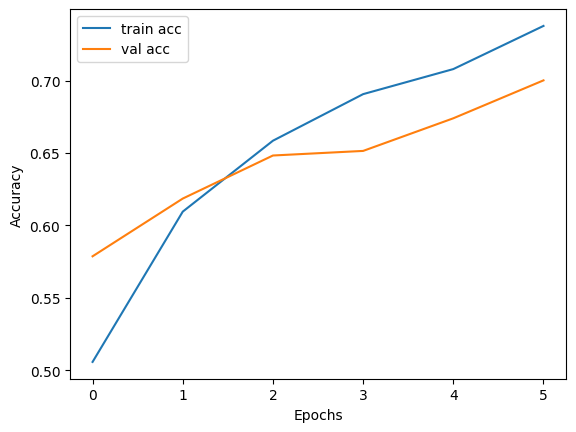

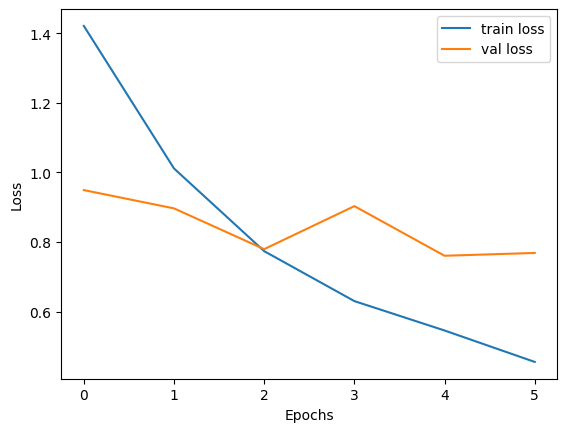

247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
                      precision    recall  f1-score   support

             Anxiety       0.77      0.81      0.79       576
             Bipolar       0.69      0.83      0.75       417
          Depression       0.77      0.35      0.48      2311
              Normal       0.94      0.91      0.92      2452
Personality disorder       0.44      0.79      0.57       161
              Stress       0.56      0.62      0.59       388
            Suicidal       0.50      0.84      0.63      1598

            accuracy                           0.70      7903
           macro avg       0.67      0.73      0.68      7903
        weighted avg       0.75      0.70      0.69      7903

[[ 465   20   10   13   17   45    6]
 [  17  345    4    7   19   22    3]
 [  38   81  808   66   45   42 1231]
 [  39    7   35 2238   25   59   49]
 [   5    8    3    9  127    9    0]
 [  30   17   19   14   42  241   25]
 [   9   20  169   41   11    9 1339]]


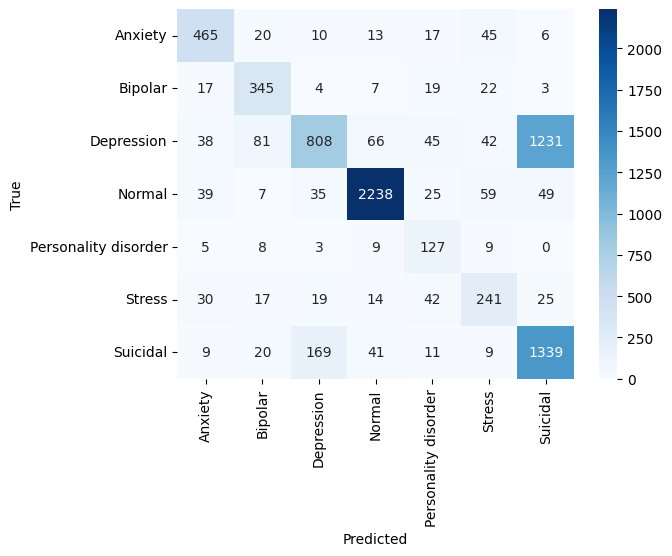

In [ ]:
# Evaluate the model
# Accuracy & loss plots
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.show()

# Evaluation on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))

confusion_matrix_sns = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix_sns, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Save Model, Tokenizer, and LabelEncoder
# Name for your model version
model_subdir = "bilstm_v1"
models_dir = str(MODEL_DIR)
this_model_dir = os.path.join(models_dir, model_subdir)
os.makedirs(this_model_dir, exist_ok=True)

model_path = os.path.join(this_model_dir, "model.keras")
tokenizer_path = os.path.join(this_model_dir, "tokenizer.pkl")
labelencoder_path = os.path.join(this_model_dir, "label_encoder.pkl")

model.save(model_path)

with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)

with open(labelencoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"Saved to {models_dir, model_subdir}")

Saved to ('/content/drive/MyDrive/MathForDeepLearning_Project/models', 'bilstm_v1')


In [ ]:

# Load tokenizer and label encoder
with open(MODEL_DIR / 'bilstm_v1' / 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open(MODEL_DIR / 'bilstm_v1' / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load the trained model
model_path = MODEL_DIR / 'bilstm_v1' / 'model.keras'
model = load_model(model_path)

# Example: Try your own texts
custom_texts = [
    df[df.status == "Suicidal"].iloc[0].statement,
    df[df.status == "Depression"].iloc[0].statement,
    df[df.status == "Anxiety"].iloc[0].statement,
     "I can't sleep at night and my heart is always racing.",
    "Life feels hopeless, I don't see a way out.",
    "I feel energetic and stable lately.",
    "Sometimes I feel extremely high, other times really low.",
    "My thoughts are everywhere, it's hard to focus.",
    "I'm feeling okay and content with life.",
    "I'm struggling with my identity and who I am."
]

# Tokenize and pad
seqs = tokenizer.texts_to_sequences(custom_texts)
padded = pad_sequences(seqs, maxlen=100)  # Use the same maxlen as training

# Predict
pred_probs = model.predict(padded)
pred_classes = np.argmax(pred_probs, axis=1)
pred_labels = le.inverse_transform(pred_classes)

# Show results
# for text, label in zip(custom_texts, pred_labels):
#     print(f"Input: {text}\nPredicted sentiment: {label}\n")

for text, probs in zip(custom_texts, pred_probs):
    print(f"{text}\nProbabilities: {probs}\nPredicted: {le.inverse_transform([np.argmax(probs)])[0]}\n")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
Input: I am so exhausted of this. Just when I think I can finally rest, just when I think maybe things are starting to settle, another hurdle comes flying at me. This month alone we found out my mum could be dying, my girlfriend left me, my parents revealed that they wanted a divorce, my grandad was hospitalised again and just now my little sister's been rushed to A&amp;E with possible brain damage. If there is a god up there they must fucking hate me. it is like life is trying to get me to kill myself and honestly I think I would be better off dead. I attempted when I was 12 but I was stupid and there was no way I could cut deep enough. Now I am 15 and everything is so much worse than it ever has been and I just cannot hold on much longer -- it is going to take a miracle to get me through this. I feel so alone. I feel like the world hates me and I have no idea what I did wrong to deserve this. I thought I was getting better. I was doing so well a

In [ ]:
print(df['status'].value_counts())

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64
